<a href="https://colab.research.google.com/github/nicolasvgot-alt/Integraci-n-de-datos-y-prospecci-n/blob/main/Primer_caso1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt



from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
Nv = '/content/1. FallasTecnológicas (1).xlsx'
datos = pd.read_excel(Nv, sheet_name=0, header=1)
datos.head(10)

,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas (Freq),Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."
5,2009-01-06,100,31.5177,3,0.2363,"Errores visuales menores, problemas de usabili..."
6,2009-01-07,115,29.5603,1,0.2737,"Errores visuales menores, problemas de usabili..."
7,2009-01-08,90,36.4063,8,12.4245,"Caída total del sistema por más de 24 horas, p..."
8,2009-01-09,105,9.3552,1,2.3869,"Degradación del rendimiento por varias horas, ..."
9,2009-01-10,85,23.7019,7,0.3098,"Errores visuales menores, problemas de usabili..."


In [4]:
del datos['Fechas']

In [ ]:
datos

,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas (Freq),Valor Generado Promedio (Millones),Descripción Evento
0,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."
...,...,...,...,...,...
696,120,12.4392,1,0.5747,"Errores visuales menores, problemas de usabili..."
697,115,16.5890,6,0.7209,"Errores visuales menores, problemas de usabili..."
698,115,24.3684,10,0.3628,"Errores visuales menores, problemas de usabili..."
699,80,9.6770,4,0.2715,"Errores visuales menores, problemas de usabili..."


In [5]:
Freq=datos.iloc[:,2]
Sev=datos.iloc[:,3]


In [6]:
LDA = Freq*Sev


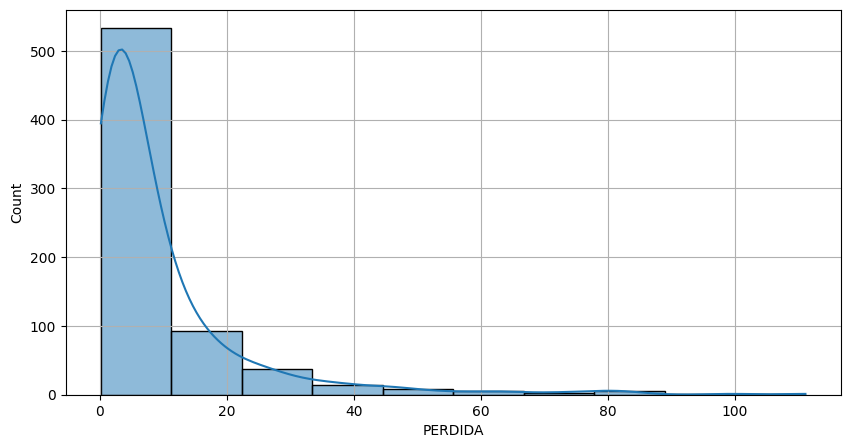

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(LDA,bins=10,kde=True)
plt.xlabel('PERDIDA')
plt.grid()
plt.show()

In [10]:
np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
NI = 10
counts, bin_edges=np.histogram(LDA,bins=NI)
print("El número de datos por intervalo es:")
print(counts)
print("Los intervalos inferiores:")
print(bin_edges[:-1])
print("Los intervalos superiores:")
print(bin_edges[1:])
XC = (bin_edges[:-1]+ bin_edges[1:])/2
print("Los intervalos centrales:")
print(XC)

Tabla =np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
df=pd.DataFrame(Tabla,columns=['LMI','LMSup','Cent','Frecuencia'])
df

El número de datos por intervalo es:
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores:
[ 0.14 11.24 22.33 33.42 44.52 55.61 66.71 77.8  88.89 99.99]
Los intervalos superiores:
[ 11.24  22.33  33.42  44.52  55.61  66.71  77.8   88.89  99.99 111.08]
Los intervalos centrales:
[  5.69  16.78  27.88  38.97  50.07  61.16  72.25  83.35  94.44 105.54]


,LMI,LMSup,Cent,Frecuencia
0,0.14230,11.23637,5.689335,533.0
1,11.23637,22.33044,16.783405,93.0
2,22.33044,33.42451,27.877475,37.0
3,33.42451,44.51858,38.971545,14.0
4,44.51858,55.61265,50.065615,9.0
5,55.61265,66.70672,61.159685,5.0
6,66.70672,77.80079,72.253755,3.0
7,77.80079,88.89486,83.347825,5.0
8,88.89486,99.98893,94.441895,1.0
9,99.98893,111.08300,105.535965,1.0


In [12]:
u=np.mean(LDA)
var=np.var(LDA)
sigma=np.std(LDA)
Tabla1 =np.column_stack((u,var,sigma))
df2=pd.DataFrame(Tabla1,columns=['Media','Varianza','Desviación'])
df2

,Media,Varianza,Desviación
0,9.451113,187.894776,13.707472


In [13]:
from scipy.stats import skew, kurtosis

# Calculate Skewness and Kurtosis
SK = skew(LDA)
KUR = kurtosis(LDA)

# Create a DataFrame to display the results
df2_temp = df2.copy()
df2_temp['Asimetria'] = SK
df2_temp['Kurtosis'] = KUR

# Display the DataFrame
display(df2_temp)

,Media,Varianza,Desviación,Asimetria,Kurtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


## Análisis







-   **Media:** `9.45`
    La pérdida promedio es aproximadamente 9.45. Este valor representa la pérdida típica o esperada durante el período analizado. Una media más elevada indicaría un impacto promedio más alto y constante derivado de fallas tecnológicas.

-   **Varianza** `187.89`
  La varianza es 187.89. Esta métrica refleja el grado en que los valores individuales de pérdida se dispersan respecto a la media. Una varianza alta sugiere una amplia dispersión de los valores, lo que indica que las pérdidas pueden variar de forma significativa frente al promedio. Esto evidencia una falta de consistencia en el impacto de las fallas.

-   **Desviación:** `13.71`
  La desviación estándar es 13.71, equivalente a la raíz cuadrada de la varianza. Este indicador facilita una interpretación más intuitiva de la dispersión de las pérdidas alrededor de la media. Dado que la desviación estándar supera ampliamente el valor promedio (9.45), se concluye que existe una alta variabilidad en las pérdidas. En términos prácticos, aunque la pérdida promedio es moderada, los eventos individuales pueden ser considerablemente mayores o menores, lo que refleja un entorno de riesgo e imprevisibilidad..

-   **Asimetria** `3.35`
    La asimetría es 3.35, un valor positivo. Esto indica que la distribución de “PÉRDIDA” presenta un sesgo positivo, con una cola larga hacia la derecha.Significa que la mayoría de los eventos de pérdida son relativamente bajos, pero existen eventos poco frecuentes con pérdidas extremadamente altas que elevan el promedio. Este hallazgo es clave para la gestión del riesgo, ya que pone en evidencia la presencia de pérdidas severas, poco comunes pero de alto impacto.

-   **Kurtosis:** `14.17`
La curtosis alcanza un valor de 14.17, considerablemente superior a 3, que corresponde a una distribución normal. Esto implica una mayor probabilidad de ocurrencia de valores extremos, tanto pérdidas muy bajas como especialmente altas, en comparación con una distribución normal. Este resultado refuerza la conclusión derivada de la asimetría: existe una probabilidad significativa de enfrentar fallas tecnológicas excepcionales, raras pero con un impacto financiero considerable.

## Análisis de perdidas






1.  **Rango de perdidas:**
    *  El histograma muestra de manera clara una distribución fuertemente sesgada hacia la derecha, donde la gran mayoría de los valores de “PÉRDIDA” se concentran en los rangos más bajos.
El primer intervalo, [0.14230, 11.23637], agrupa 533 de 701 observaciones, lo que indica que la mayoría de las pérdidas son relativamente pequeñas.
El segundo rango con mayor frecuencia es [11.23637, 22.33044], con 93 ocurrencias.

Este comportamiento confirma que las pérdidas más frecuentes tienden a ser de baja magnitud.

2.  **Presencia de clústeres diferenciadoss:**
    * La distribución no evidencia clústeres claramente definidos. En su lugar, se observa una disminución continua y pronunciada de la frecuencia a medida que aumenta el nivel de pérdida. La alta concentración de valores en los primeros intervalos se va diluyendo gradualmente, lo que sugiere la existencia de un único clúster dominante de pérdidas pequeñas acompañado de una cola larga compuesta por pérdidas mayores menos frecuentes.

3.  **Significant Outliers or 'Fat Tail' Events:**
    *   La prolongada cola derecha del histograma, junto con la información del DataFrame, evidencia la presencia de valores atípicos relevantes o eventos de “cola pesada” (fat tail). Aunque la mayoría de las pérdidas son pequeñas, existen eventos poco frecuentes pero de gran magnitud. Por ejemplo, los intervalos:

[77.80079, 88.89486] con 5 ocurrencias

[88.89486, 99.98893] con 1 ocurrencia

[99.98893, 111.08300] con 1 ocurrencia

Estos valores, si bien son raros, representan pérdidas sustancialmente superiores a las habituales y son coherentes con los altos niveles de asimetría (3.35) y curtosis (14.17) previamente calculados, indicadores típicos de distribuciones con colas pesadas y valores extremos.



**Hallazgos**



1. La distribución de PERDIDA presenta un fuerte sesgo positivo (asimetría = 3.35) y una curtosis elevada (14.17), con una pérdida promedio aproximada de 9.45 millones y una desviación estándar de 13.71 millones. El histograma evidencia que la gran mayoría de los eventos (533 de 701, equivalentes a aproximadamente 76%) se concentran en el intervalo de pérdidas más bajo (0.14 a 11.24 millones). No obstante, la presencia de una cola larga hacia la derecha indica que, aunque los eventos menores son frecuentes, existen eventos severos y de alto impacto que, si bien son poco comunes, contribuyen de manera significativa al riesgo total.

**Implicación para el negocio**:
Si bien las operaciones diarias están marcadas por múltiples pérdidas de bajo impacto, la organización debe estar plenamente consciente y preparada frente a eventos poco frecuentes pero de gran magnitud. Las estrategias de gestión del riesgo deben equilibrar la eficiencia en el manejo de incidentes menores con planes de contingencia robustos y una adecuada asignación de capital para enfrentar pérdidas catastróficas. Esto sugiere la necesidad de una mitigación de riesgos diversificada, en lugar de una visión centrada exclusivamente en los promedios.

2.  La varianza elevada (187.89) y la desviación estándar (13.71), en relación con la media (9.45), evidencian una alta volatilidad en la magnitud de las pérdidas. Esto implica que los eventos reales pueden desviarse de forma considerable del valor promedio. El amplio rango de la distribución, que va desde 0.14 hasta 111.08 millones, refuerza el carácter impredecible de estos eventos.

**Implicación para el negocio**:
La volatilidad en las pérdidas dificulta la proyección financiera y la presupuestación asociada a eventos de riesgo. Los modelos estadísticos tradicionales que asumen distribuciones normales tienden a subestimar los riesgos de cola. En este contexto, resulta crítico implementar sistemas de monitoreo dinámico del riesgo y escenarios de stress testing enfocados en eventos extremos, con el fin de fortalecer la preparación y la estabilidad financiera. Asimismo, se hace evidente la conveniencia de mecanismos sólidos de aseguramiento o autoaseguramiento para absorber impactos de alta variabilidad.

3.  *El análisis de frecuencias (DataFrame df) muestra una caída abrupta en el número de eventos a medida que aumenta la magnitud de la pérdida. Por ejemplo, el primer intervalo (0.14 – 11.24 millones) concentra 533 eventos, el segundo (11.24 – 22.33 millones) 93 eventos, y los intervalos posteriores presentan frecuencias decrecientes de forma acelerada, llegando a registrarse solo 1 evento en los rangos más altos. Este patrón sugiere la existencia de categorías diferenciadas de eventos de pérdida.

Implicación para el negocio:
Esta segmentación indica que distintos factores explican las pérdidas frecuentes de baja magnitud frente a las pérdidas raras de alto impacto. Desde una perspectiva operativa, resulta prioritario identificar y mitigar las causas raíz de los eventos pequeños y recurrentes para reducir su impacto acumulado y mejorar la eficiencia diaria. Paralelamente, se requiere un enfoque específico y especializado para identificar, prevenir y gestionar los eventos de “cola pesada”, que probablemente demanden metodologías analíticas y medidas preventivas distintas, orientadas a fallas catastróficas. La adopción de estrategias diferenciadas por segmento de pérdida permitiría una asignación más eficiente de los recursos en la gestión integral del riesgo.